**Author:** Christopher Millward<br>
**Date:** August 14, 2026

The purpose of this notebook is to develop the function to visualize the heatmap distributions. 

---

Steps:
1. Write logic to plot one heatmap
2. Visualize all participants in one subplot
3. Build function to plot the avg 

In [1]:
import os 
import sys

# set root folder to project root
root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
from matplotlib.ticker import StrMethodFormatter
from matplotlib import cm 

from config import RESULTS_PICKLE_PATH
from schema import ParticipantDetails, Heatmap

# CRITICAL: This tells Jupyter to use an interactive window that allows real-time loop updates.
# If '%matplotlib notebook' fails or is not installed, change it to '%matplotlib widget'
%matplotlib widget

In [3]:
# import pickle file
with open(Path(RESULTS_PICKLE_PATH), 'rb') as f:
    results: list[ParticipantDetails] = pickle.load(f)

participant = results[0]
heatmap: Heatmap = participant.right.humerothoracic.heatmap

## 1. Write logic to plot one heatmap

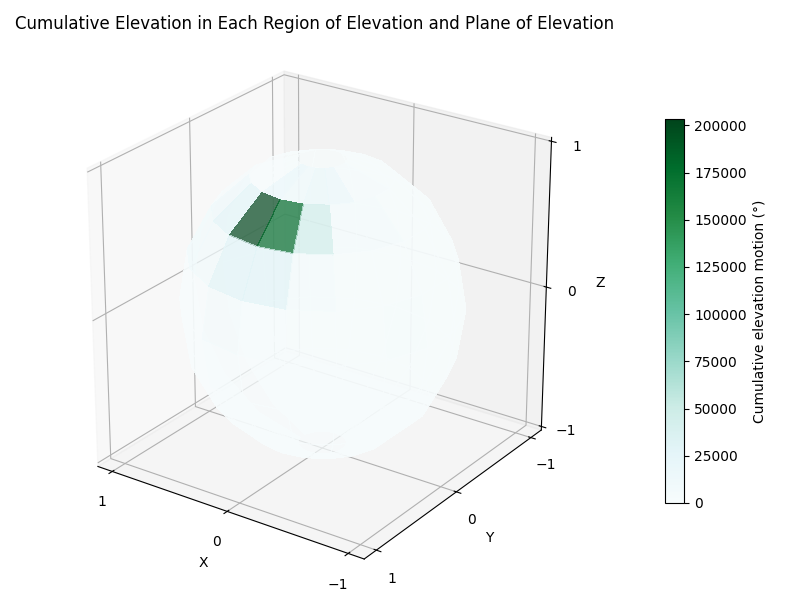

In [7]:
elevation_data = heatmap.elevation
n_elevation, n_poe = elevation_data.shape

# Bin centres in degrees
elevation = (np.arange(n_elevation) + 0.5) * heatmap.bin_width
poe = (np.arange(n_poe) + 0.5) * heatmap.bin_width

# Convert bins to radians
theta = np.deg2rad(elevation)   # polar angle
phi = np.deg2rad(poe)           # azimuth

# Create 2D spherical coordinate grids
phi_grid, theta_grid = np.meshgrid(phi, theta)

# Convert spherical coordinates -> Cartesian coordinates
x = np.sin(theta_grid) * np.cos(phi_grid)
y = np.sin(theta_grid) * np.sin(phi_grid)
z = np.cos(theta_grid)

# Create color map 
cmap = "BuGn"
norm = Normalize(
    vmin=float(np.nanmin(elevation_data)),
    vmax=float(np.nanmax(elevation_data)),
)
colors = plt.get_cmap(cmap)(norm(elevation_data))

# Plot the data 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(
    x,
    y,
    z,
    facecolors=colors,
    alpha=0.7,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
)

# Set up the color bar
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(elevation_data)
cbar = fig.colorbar(
    mappable,
    ax=ax,
    shrink=0.7,
    pad=0.1,
)
cbar.set_label("Cumulative elevation motion (°)")


# Some formatting
ax.set_box_aspect((1, 1, 1)) # Make the sphere look spherical

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.set_zticks([-1, 0, 1])

ax.view_init(
    elev=25,
    azim=125,
    roll=0,
)

ax.set_title("Cumulative Elevation in Each Region of Elevation and Plane of Elevation")

plt.tight_layout()
plt.show()

## 2. Visualize all participants in one subplot

C:\Users\chris\AppData\Local\Temp\ipykernel_11016\3700865784.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.985])


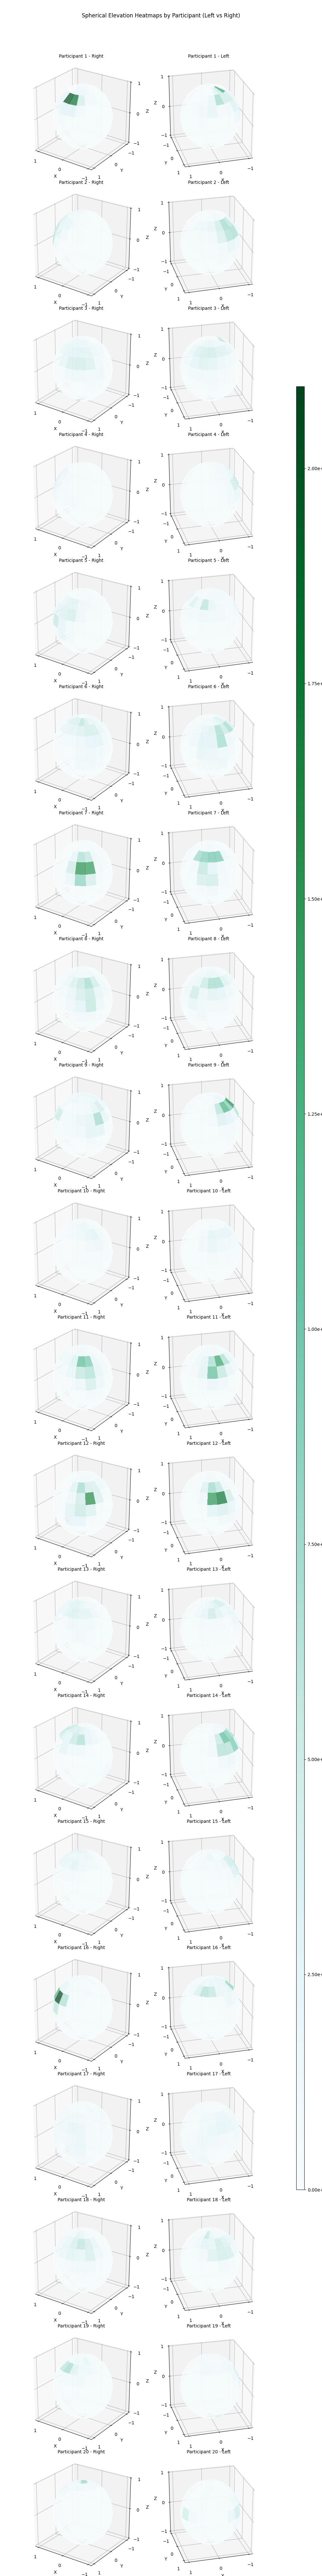

In [5]:
participants = results
n_participants = len(participants)

# Collect all elevation values to build one shared color scale across every subplot
all_elevation_values = []
for p in participants:
    all_elevation_values.append(p.left.humerothoracic.heatmap.elevation)
    all_elevation_values.append(p.right.humerothoracic.heatmap.elevation)

all_elevation_values = np.concatenate([arr.ravel() for arr in all_elevation_values])
global_vmin = float(np.nanmin(all_elevation_values))
global_vmax = float(np.nanmax(all_elevation_values))
global_norm = Normalize(vmin=global_vmin, vmax=global_vmax)
cmap_name = "BuGn"

# Plot
fig = plt.figure(figsize=(10, 4 * n_participants))

# for each participant
for row_idx, participant in enumerate(participants):
    arm_heatmaps = [
        participant.right.humerothoracic.heatmap,
        participant.left.humerothoracic.heatmap,
    ]
    # for each arm
    for col_idx, arm_heatmap in enumerate(arm_heatmaps):
        # add the subplot
        ax = fig.add_subplot(
            n_participants,
            2,
            row_idx * 2 + col_idx + 1,
            projection="3d",
        )
        # get the data
        elevation_data = arm_heatmap.elevation
        n_elevation, n_poe = elevation_data.shape

        # put bin centres in degrees
        elevation = (np.arange(n_elevation) + 0.5) * arm_heatmap.bin_width
        poe = (np.arange(n_poe) + 0.5) * arm_heatmap.bin_width

        # Spherical -> Cartesian transform
        theta = np.deg2rad(elevation)  # polar angle
        phi = np.deg2rad(poe)          # azimuth
        phi_grid, theta_grid = np.meshgrid(phi, theta)
        x = np.sin(theta_grid) * np.cos(phi_grid)
        y = np.sin(theta_grid) * np.sin(phi_grid)
        z = np.cos(theta_grid)

        # get the colors
        facecolors = plt.get_cmap(cmap_name)(global_norm(elevation_data))

        # plot it
        ax.plot_surface(
            x,
            y,
            z,
            facecolors=facecolors,
            alpha=0.7,
            rstride=1,
            cstride=1,
            linewidth=0,
            antialiased=False,
            shade=False,
        )

        # formatting
        ax.set_box_aspect((1, 1, 1))

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.set_zticks([-1, 0, 1])

        if col_idx == 0:
            ax.view_init(elev=25, azim=125, roll=0)
        else:   
            ax.view_init(elev=25, azim=75, roll=0)

        side_label = "Right" if col_idx == 0 else "Left"
        participant_label = getattr(participant, "id", None) or getattr(participant, "participant_id", None) or f"Participant {row_idx + 1}"
        ax.set_title(f"{participant_label} - {side_label}", fontsize=10)


# Create one giant colorbar for all subplots
mappable = cm.ScalarMappable(
    norm=global_norm,
    cmap=cmap_name,
)
mappable.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
)
cbar.ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:.2e}")
)
cbar.set_label("Cumulative elevation motion (°)")

fig.suptitle(
    "Spherical Elevation Heatmaps by Participant (Left vs Right)",
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 0.9, 0.985])

plt.show()

3. Build function to plot the avg 